In [ ]:
%load_ext autoreload
%autoreload 2

# Analysis of the radical OH species
## NPT
Molecular dynamics at the isobaric and isothermal ensemble was run for 100 ps at 350 K and 1.0 bar pressure in order to obtain an estimate of the liquid density.

The section below contains estimates of thermodynamic properties and the liquid structure in the form of RDFs and heatmaps which contain angular information around the hydroxyl-molecule.

### Building the trajectory

In [72]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, plot_rdf, diffusive_window
from chempiler.state_engine import atom_hop, ligand_exchange

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt = 0.5 # fs
TEMPERATURE = 350.0 # K
PRESSURE = 1.0 # bar
DUMP_INTERVAL = 10

data_path = '../../data'

NPT_LOGFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH.log'
NPT_CALCFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH_calc.h5'
NPT_TRAJFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH.traj'

In [6]:
print('Reading OH• NPT trajectory...')
traj = ChempilerTrajectory(
    NPT_TRAJFILE,
    mode='molecular', covalent_scale=0.8, # NOTE: The small covalent scale is important to capture the O-H bond in the ion. To avoid seeing clusters of water molecules as bonded. IS THIS A MOTIF 'ISSUE'?
)
print('Building topology...')
traj.build(
    cache_file='tests/OH_rad_npt_cache.h5',
    companion=NPT_CALCFILE,
    persistence=3,
)
print('Done.')
print('Molecular species in trajectory:')
traj.summary()

Reading OH• NPT trajectory...
Building topology...
[Chempiler] loaded cache → tests/OH_rad_npt_cache.h5
[Chempiler] persistence=3: corrected 1 frames
[Chempiler] companion attached → ../../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH_calc.h5 (20001 frames, 14 properties: charges, density_coefficients, dipole, electron_energy, electrostatic_energy, energies, energy, forces, free_energy, interaction_energy, node_energy, spin_charge_density, spins, stress)
Done.
Molecular species in trajectory:


{'H2O': 780033, 'HO': 20001, 'H4O2': 3}

### Summary of molecular species
Shown below is the segmentation of the trajectory based on molecular composition.

,n_segs,coverage,min,median,mean,max
formula,,,,,,
H2O,1,100.0%,20001,20001,20001.0,20001
HO,1,100.0%,20001,20001,20001.0,20001
H4O2,1,0.0%,3,3,3.0,3


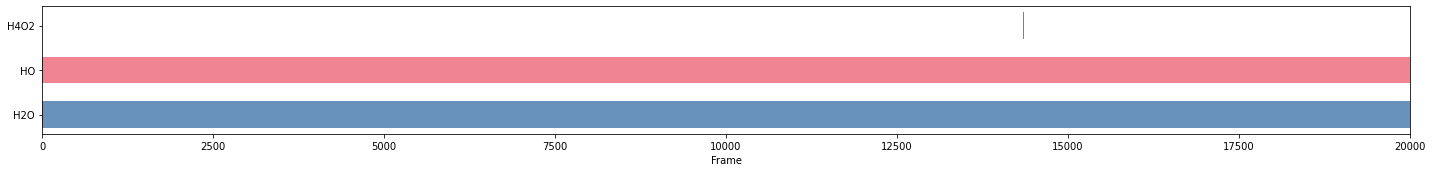

In [7]:
# Dataframe
rows = []
for formula, _ in traj.summary().items():
    segs = traj.lifetime_segments(formula)
    lengths = np.array([e - s for s, e in segs])
    covered = lengths.sum()
    rows.append({
        'formula':  formula,
        'n_segs':   len(segs),
        'coverage': f"{100 * covered / len(traj.frames):.1f}%",
        'min':      int(lengths.min()),
        'median':   int(np.median(lengths)),
        'mean':     f"{lengths.mean():.1f}",
        'max':      int(lengths.max()),
    })

species = sorted(traj.summary().keys(), key=lambda f: -traj.summary()[f])
fig, ax = plt.subplots(figsize=(20, 0.5 * len(species) + 1))

for i, (row_colour, formula) in enumerate( zip(cset, species) ):
    for s, e in traj.lifetime_segments(formula):
        ax.barh(i, e - s, left=s, height=0.6, color=row_colour, alpha=0.8)

ax.set_yticks(range(len(species)))
ax.set_yticklabels(species)
ax.set_xlabel('Frame')
ax.set_xlim(0, len(traj.frames))
plt.tight_layout()

pd.DataFrame(rows).set_index('formula')


### Thermodynamic properties
Thermodynamic properties were computed with block statistics. The independence of each block was ascertained by estimating the correlation times, $\tau$ (in dumped frames), and setting the block length to $10\tau$ (`block_factor = 10`) so that adjacent blocks are effectively uncorrelated.

The output is a *block average* (`mean`) and *standard error of the mean* (`stderr`): 
$$
\texttt{stderr} = \frac{\sigma_{\texttt{block}}}{\sqrt{\texttt{n\_blocks}}}
$$

**Results:**

In [ ]:
import json

import utils.helper_funcs as hf
import utils.thermo_funcs as tf


NPT_paths = {
    'OH$^*$(aq)': '/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/',
}
cache_file = 'results/NPT/OH_radical_thermo_props.json'


try:
    with open(cache_file, 'r') as f:
        cached_thermo_props = json.load(f)
    print("Loaded cached thermodynamic properties.")
    correlation_times = cached_thermo_props['correlation_times']
    block_factor = cached_thermo_props['block_factor'] # Number of correlation times between uncorrelated blocks

except FileNotFoundError:
    print("No cache found: Computing correlation times and thermodynamic properties.")
    block_factor = 10 # Number of correlation times between uncorrelated blocks

    # Compute correlation times
    traj_data = hf.load_data(
        NPT_paths,
        fname='*.traj',
        root_dir=data_path
    )

    # Check for unreliable estimates
    tau_dict, unreliable = tf.estimate_correlation_times(traj_data)
    if unreliable:
        print('Unreliable correlation-time estimates:', unreliable)

    # Round to whole frames
    correlation_times = {
        prop: round(tau) for prop, tau in tau_dict['OH$^*$(aq)'].items()
    }

POLAR_thermo_df = hf.cached_thermo_props(
    cache_file,
    NPT_paths,
    data_path,
    temperature=TEMPERATURE,
    correlation_times=correlation_times,
    block_factor=block_factor,
)
POLAR_thermo_df

Loaded cached thermodynamic properties.
Loaded thermodynamic properties from results/OH_radical_thermo_props.json
  correlation_times used: {'volume': 93, 'density': 93, 'enthalpy': 75, 'pressure': 1, 'heat_capacity': 75, 'compressibility': 93, 'bulk_modulus': 93, 'thermal_expansion': 93}
  temperature used: 350.0
  block_factor used: 10


---
---
TODO:
- Run pure water (39 molecules). I have run 40 molecules but this is not usable. Remove 1, equilibrate, and run NPT.
  - Then we can compare better to pure water, and also compute solvation enthalpy of the OH species
---
---

### Liquid structure
The simulation box is very small so only the early peaks can be properly assessed. The automated `rmax` is based on the *smallest* box size across the NPT trajectory.

The $\text{O}_\text{rad} \cdots \text{O}_\text{w}$ species show a clear peak located at the **hemi-bond** distance.

[Chempiler] loaded RDF cache → results/rdf_Orad_Ow.json
  Peaks:   2.125,  2.975,  4.725
  CNs:     1.017,  11.779,  20.124
[Chempiler] loaded RDF cache → results/rdf_Orad_Hw.json
  Peaks:   2.325,  3.325
  CNs:     5.558,  41.088
[Chempiler] loaded RDF cache → results/rdf_Hrad_Ow.json
  Peaks:   2.175,  3.325
  CNs:     2.414,  20.409


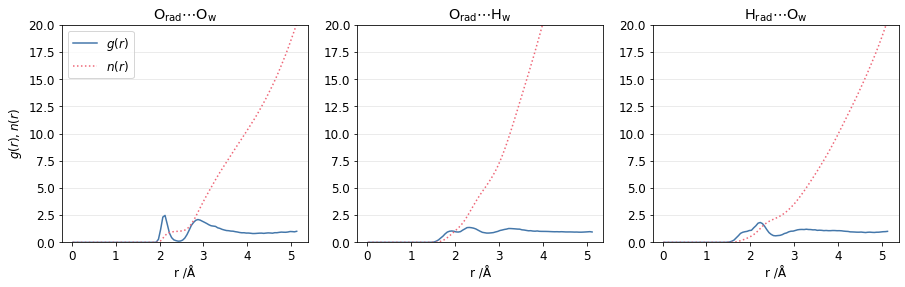

In [ ]:
from chempiler import rdf_shells

plts = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "O"}, {"H2O": "O"}, 'results/NPT/rdf_Orad_Ow.json'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"HO": "O"}, {"H2O": "H"}, 'results/NPT/rdf_Orad_Hw.json'),
    '$\\text{H}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "H"}, {"H2O": "O"}, 'results/NPT/rdf_Hrad_Ow.json'),
}

fig, axs = plt.subplots(1,3, figsize=(3*5, 4))
for ax, (label, pair) in zip(axs, plts.items()):
    CTR, TGT, CACHE = pair

    r, g, n = traj.rdf(
        center=CTR,
        target=TGT,
        dr=0.05,
        integrate=True,
        cache_file=CACHE,
    )
    shells = rdf_shells(r, g, n, smooth_sigma=0.2)

    peaks = [str(p) for p in shells.peaks.round(decimals=3)]; print('  Peaks:  ', ',  '.join(peaks))
    cns = [str(c) for c in shells.cns.round(decimals=3)]; print('  CNs:    ', ',  '.join(cns))

    ax.plot(r,g, label='$g(r)$')
    ax.plot(r,n, ':', label='$n(r)$')

    ax.set_title(label)
    ax.set_xlabel('r /Å')
    ax.set_ylim(0,20)
    ax.grid(axis='y')

axs[0].set_ylabel('$g(r), n(r)$')
axs[0].legend();

In [88]:
from chempiler import spatial_density_maps, plot_sdf_panel, plot_sdf

targets = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"H2O": "O"}, 'results/NPT/sdf_Orad_Ow.h5'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"H2O": "H"}, 'results/NPT/sdf_Orad_Hw.h5'),
}

panels = {
    label: spatial_density_maps(
        traj.frames,
        center={"HO": "O"},
        align_to={"HO": "H"},
        target=pair,
        symmetry='Cinfv',
        rmax=5.0, bins=75, stride=1,
        cache_file=cache,
    )
    for label, (pair, cache) in targets.items()
}


[Chempiler] saved SDF cache → results/NPT/sdf_Orad_Ow.h5
[Chempiler] saved SDF cache → results/NPT/sdf_Orad_Hw.h5


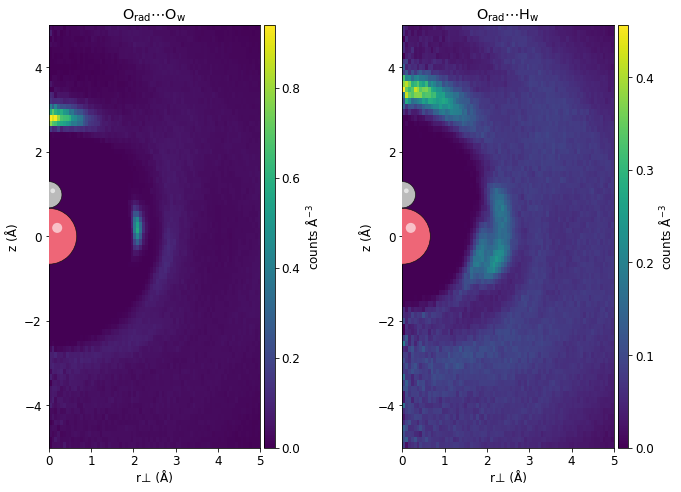

In [89]:
fig, axs = plt.subplots(1, len(panels), figsize=(5 * len(panels), 7))

for ax, (label, data) in zip(axs, panels.items()):
    ax.plot_sdf(
        data,
        projection='cylindrical',
        center_symbol='O',
        align_symbol='H',
        normalize='density',
        cmap='viridis',
        #render='contour', # ??????????????
        # MIN COUNT?
        # MAX COUNT? COLOURBARS SHOULD BE SAME IN BOTH FIGURES
    )
    ax.set_title(label)

plt.tight_layout()

### Cluster analysis

In [90]:

clusters = traj.extract_nearest_neighbors(
    'HO', n_neighbors=4,
    output_dir='results/NPT',
    stride=1,           # or frame_indices=[...] for specific frames
)

  Written results/NPT/HO_nn4.xyz  (20001 frames)


In [111]:
from chempiler import view3d
from ase.io import read

atoms = read('results/NPT/HO_nn4.xyz', index=1)
o_idx = [i for i, s in enumerate(atoms.get_chemical_symbols()) if s == 'O']

view3d(atoms, mark_atoms=o_idx)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [112]:

labels = {i: str(i) for i in o_idx}       # default: every oxygen shows its atomic index
labels = {
    0: 'O1',
    3: 'O2',
    6: 'O3',
    9: 'O4',
    12: 'O*',
}
view3d(atoms, mark_atoms=labels)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.